In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import display
import h5py
from PIL import Image
from io import BytesIO

# Introduction 

### It is my first time publishing a data exploration notebook, if you have feedback please comment so that I can improve! :D

I will expand this notebook if I find more interestings things

In [2]:
data = pd.read_csv('/kaggle/input/isic-2024-challenge/train-metadata.csv')

/tmp/ipykernel_19/2593239311.py:1: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/kaggle/input/isic-2024-challenge/train-metadata.csv')


In [3]:
display(data.columns)

Index(['isic_id', 'target', 'patient_id', 'age_approx', 'sex',
       'anatom_site_general', 'clin_size_long_diam_mm', 'image_type',
       'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext',
       'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L',
       'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio',
       'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB',
       'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm',
       'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple',
       'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border',
       'tbp_lv_norm_color', 'tbp_lv_perimeterMM',
       'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt',
       'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y',
       'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id',
       'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5',
       'mel_mitotic_index', '

In [4]:
display(data)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,0,IP_1140263,70.0,male,anterior torso,6.80,TBP tile: close-up,3D: XP,22.574335,...,IL_9520694,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999988
401055,ISIC_9999951,0,IP_5678181,60.0,male,posterior torso,3.11,TBP tile: close-up,3D: white,19.977640,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999820
401056,ISIC_9999960,0,IP_0076153,65.0,female,anterior torso,2.05,TBP tile: close-up,3D: XP,17.332567,...,IL_9852274,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999416
401057,ISIC_9999964,0,IP_5231513,30.0,female,anterior torso,2.80,TBP tile: close-up,3D: XP,22.288570,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000


In [5]:
data.describe()

,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,63.000000,4.010590e+05
mean,0.000980,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.670952,9.716220e+01
std,0.031288,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.792798,8.995782e+00
min,0.000000,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.300000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.600000,9.999996e+01
max,1.000000,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


# 400666 Negative Classes and 393 Positive Classes

In [6]:
print(data['target'].value_counts())

target
0    400666
1       393
Name: count, dtype: int64


In [7]:
print(data['patient_id'].value_counts())
print(data['patient_id'].nunique())

patient_id
IP_1117889    9184
IP_5714646    6267
IP_3921915    5568
IP_7797815    4454
IP_9577633    3583
              ... 
IP_5792391       1
IP_1216329       1
IP_4004571       1
IP_1487179       1
IP_7696347       1
Name: count, Length: 1042, dtype: int64
1042


# Should we remove the ones that have low confidence?

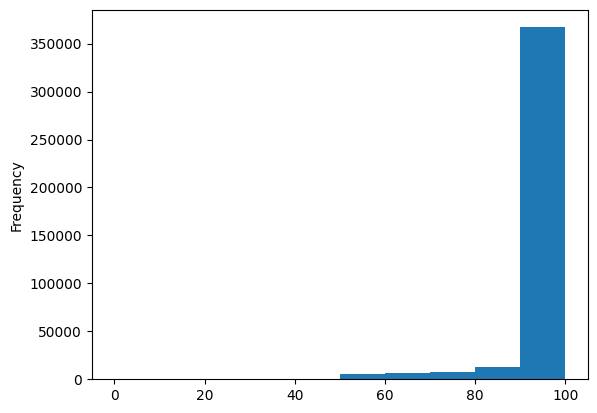

In [8]:
confidence_values = data['tbp_lv_dnn_lesion_confidence']
confidence_plot = confidence_values.plot.hist()

# Now let's see how many NaN values are in the data

<BarContainer object of 55 artists>

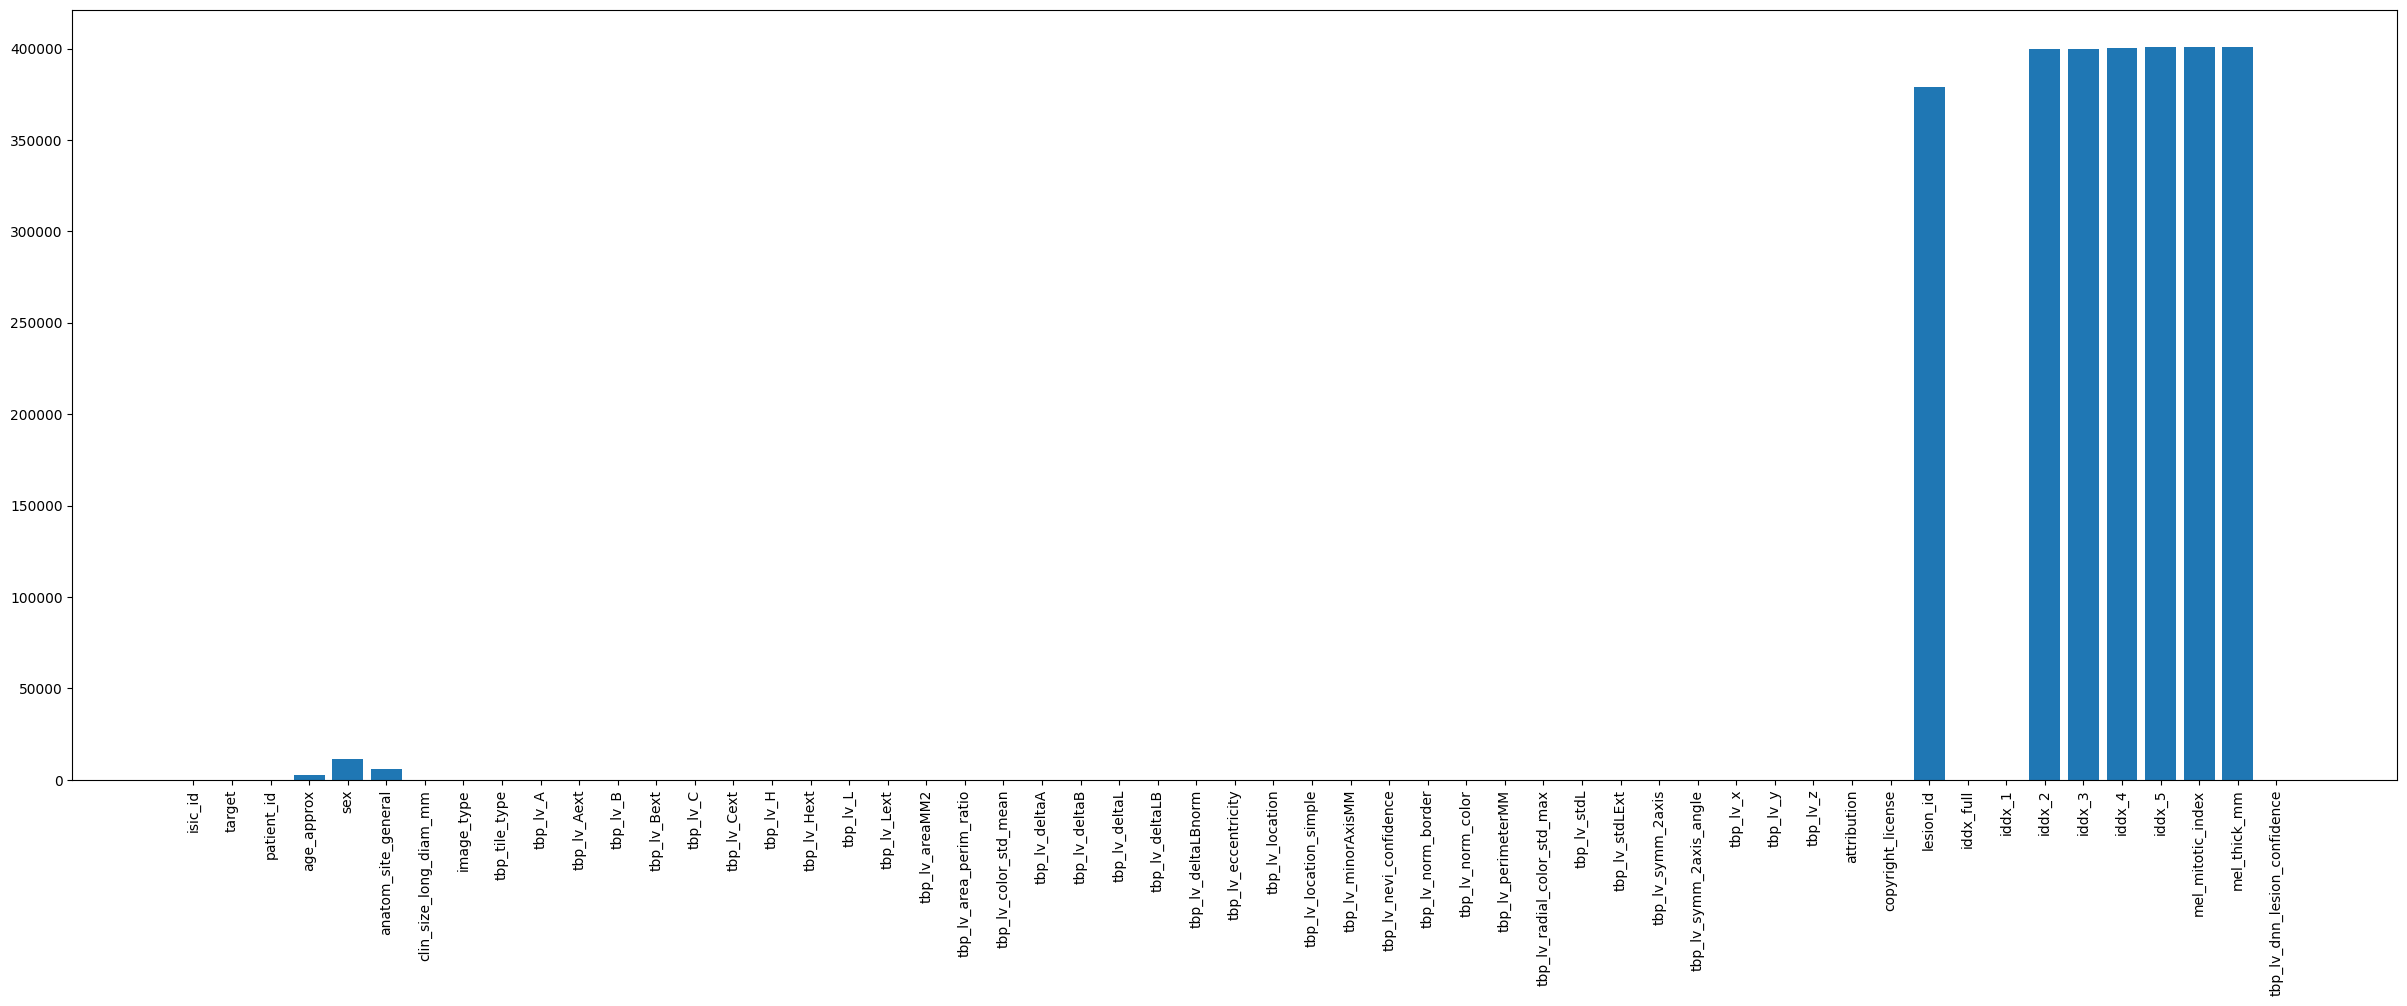

In [9]:
nan_columns = []
nan_values = []

for column in data.columns:
    nan_columns.append(column)
    nan_values.append(data[column].isna().sum())
    
fig, ax = plt.subplots(figsize=(30,10))
plt.xticks(rotation=90)
plt.bar(nan_columns, nan_values)

# Now let's look at the HDF5 train file

## For reading the files I will use the h5py python library.

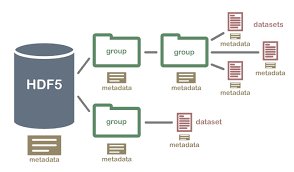

Read more about it here: https://www.neonscience.org/resources/learning-hub/tutorials/about-hdf5

Group: A folder like element within an HDF5 file that might contain other groups OR datasets within it.

Dataset: The actual data contained within the HDF5 file. Datasets are often (but don't have to be) stored within groups in the file.

In [10]:
# Running this quick but dirty code showed me that the h5py just contains all the image files, so we do not have to worry about additional groups or other weird layouts during processing.

image_data_filename = '/kaggle/input/isic-2024-challenge/train-image.hdf5'

counter = 0
max_items_to_print = 5

def visit_and_print(name):
    global counter
    if counter < max_items_to_print:
        print(name)
        counter += 1

with h5py.File(image_data_filename, 'r') as file:
    file.visit(visit_and_print)

ISIC_0015670
ISIC_0015845
ISIC_0015864
ISIC_0015902
ISIC_0024200


In [11]:
isic_ids = data['isic_id']
print(isic_ids.head())

0    ISIC_0015670
1    ISIC_0015845
2    ISIC_0015864
3    ISIC_0015902
4    ISIC_0024200
Name: isic_id, dtype: object


## The images are in binary format so for this we will use the PIL and BytesIO library

### I will also save some images

Image size: 139x139
Saved image to /kaggle/working/ISIC_0015670.png
Image size: 127x127
Saved image to /kaggle/working/ISIC_0015845.png
Image size: 145x145
Saved image to /kaggle/working/ISIC_0015864.png
Image size: 109x109
Saved image to /kaggle/working/ISIC_0015902.png
Image size: 125x125
Saved image to /kaggle/working/ISIC_0024200.png


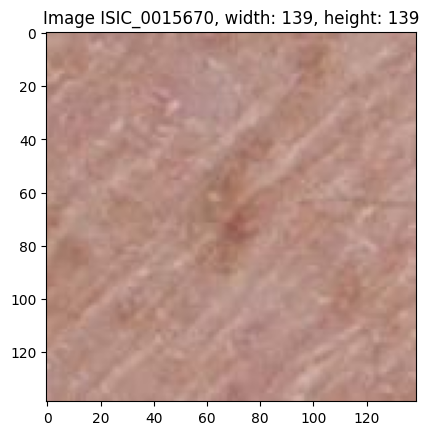

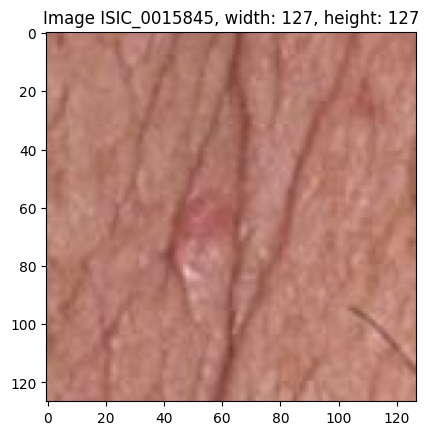

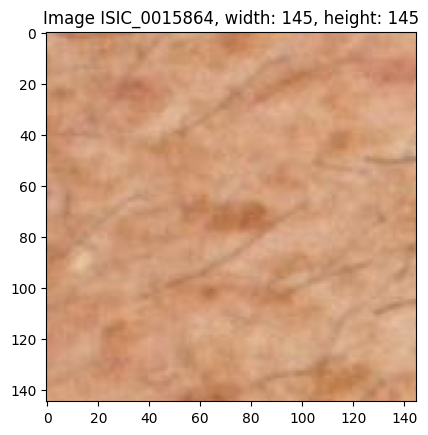

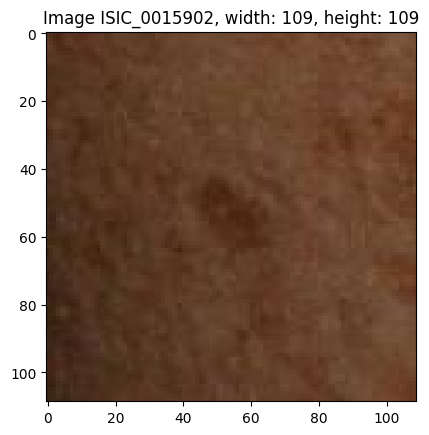

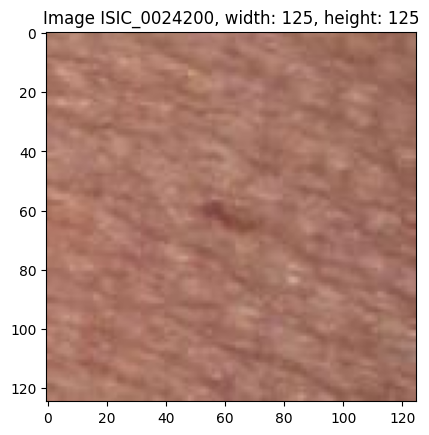

In [12]:
with h5py.File(image_data_filename, 'r') as file:
    num_images_to_display = 5

    for i in range(num_images_to_display):
        isic_id = isic_ids[i]
                
        binary_data = file[isic_id][()]

        image = Image.open(BytesIO(binary_data))
        
        width, height = image.size
        print(f'Image size: {width}x{height}')
        
        plt.figure()
        plt.imshow(image)
        plt.title(f'Image {isic_id}, width: {width}, height: {height}')
        
        image_save_path = f'/kaggle/working/{isic_id}.png'
        print(f'Saved image to {image_save_path}')
    
    plt.show()

# Looks like all the images have varying sizes.

Maybe its useful to convert the HDF5 file into PNG dataset for easier usability.

That was it for my current data exploration! I hope I showed you something interesting.